In [1]:
import os
import urllib.request
import zipfile
import tarfile
import numpy as np
import cv2 as cv
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import drive

print("Tensorflow verzija: " + tf.__version__)
print("Keras verzija: " + tf.keras.__version__)

Tensorflow verzija: 2.19.0
Keras verzija: 3.13.2


In [2]:
########################################################################################################################
# 1. MONTIRANJE GOOGLE DRIVE-A I PODEŠAVANJE PUTANJA
########################################################################################################################

drive.mount('/content/drive')

# Putanja na Google Drive-u gde će se čuvati rezultati
drive_results_folder = '/content/drive/MyDrive/Caltech101_v2_Results_Keras'
if not os.path.exists(drive_results_folder):
    os.makedirs(drive_results_folder)
    print(f"Napravljen direktorijum za rezultate na Drive-u: {drive_results_folder}")

Mounted at /content/drive
Napravljen direktorijum za rezultate na Drive-u: /content/drive/MyDrive/Caltech101_v2_Results_Keras


In [3]:
########################################################################################################################
# 2. PREUZIMANJE I RASPAKIVANJE PODATAKA
########################################################################################################################

dataset_url = "https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip"
zip_path = "/content/caltech-101.zip"
caltech_folder = "/content/caltech-101"
data_folder = "/content/101_ObjectCategories"

if not os.path.exists(zip_path):
    print("Preuzimanje dataseta...")
    urllib.request.urlretrieve(dataset_url, zip_path)
    print("Preuzimanje završeno.")

if not os.path.exists(caltech_folder):
    print("Raspakivanje osnovne ZIP arhive...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')

if not os.path.exists(data_folder):
    print("Raspakivanje slika iz TAR.GZ arhive...")
    tar_path = os.path.join(caltech_folder, '101_ObjectCategories.tar.gz')
    with tarfile.open(tar_path, 'r:gz') as tar_ref:
        tar_ref.extractall('/content/')
    print("Slike su spremne.")

Preuzimanje dataseta...
Preuzimanje završeno.
Raspakivanje osnovne ZIP arhive...
Raspakivanje slika iz TAR.GZ arhive...


/tmp/ipykernel_869/3781274065.py:24: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar_ref.extractall('/content/')


Slike su spremne.


<Figure size 640x480 with 0 Axes>

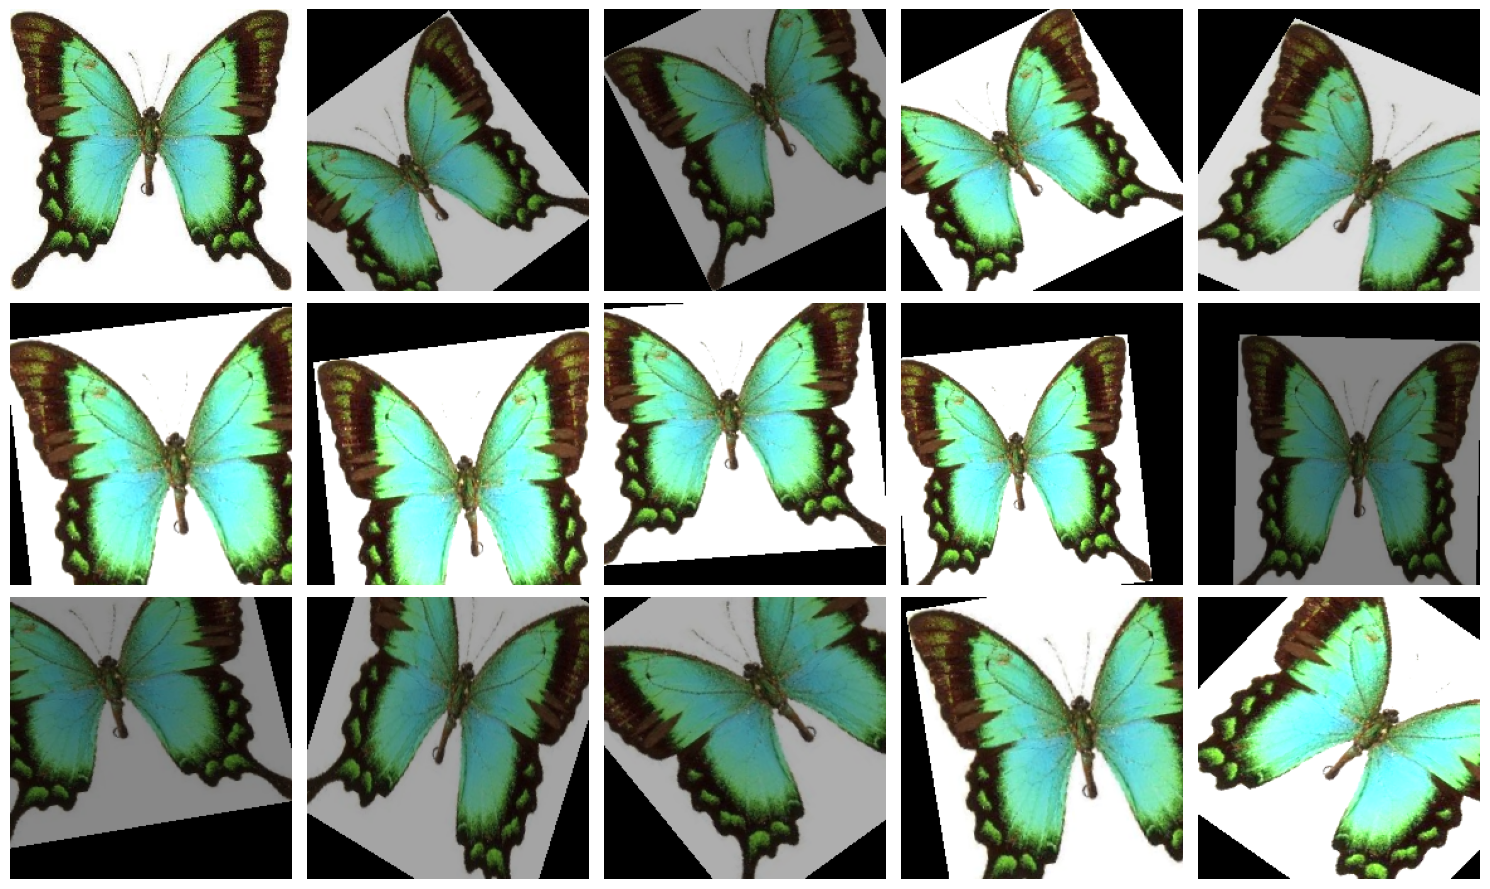

In [4]:
########################################################################################################################
# 3. DATA AUGMENTATION
########################################################################################################################

def get_data_generator():
    return tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=45,
                                                           width_shift_range=0.2,
                                                           height_shift_range=0.2,
                                                           brightness_range=(0.5, 1.5),
                                                           shear_range=0.1,
                                                           zoom_range=0.2,
                                                           fill_mode='constant', #'constant', 'nearest', 'reflect'
                                                           cval=0,
                                                           horizontal_flip=True,
                                                           vertical_flip=False,
                                                           validation_split=0.0,
                                                           dtype=np.float32)

# Test data augmentation
img = cv.imread(os.path.join(data_folder, 'butterfly', 'image_0018.jpg'))
img = cv.resize(img, (224, 224))
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.clf()
plt.figure(figsize=(15, 9))  # Širina i visina prozora za prikaz

data_gen = get_data_generator()
for i in range(15):
    if i == 0:
        img_da = img
    else:
        img_da = data_gen.random_transform(img)
        img_da = np.clip(img_da, 0, 255).astype(np.uint8)
    plt.subplot(3, 5, i + 1)  # Kreiranje grida: 3 reda, 5 kolona, i-ta pozicija
    plt.imshow(img_da)
    plt.axis('off')  # Isključivanje x i y osa radi preglednijeg prikaza slika

plt.tight_layout()  # Automatsko podešavanje razmaka između slika
plt.show()          # Prikaz grida u Colab ćeliji

In [5]:
########################################################################################################################
# 4. PODRŠKA ZA UČITAVANJE I AUGMENTACIJU PODATAKA
########################################################################################################################

def load_data_def():
    categories = []
    train_images = []
    test_images = []

    image_folders = sorted(os.listdir(data_folder))
    for c in image_folders:
        # Izbacivanje kategorije BACKGROUND_Google
        if c == 'BACKGROUND_Google':
            continue

        path = os.path.join(data_folder, c)
        if os.path.isdir(path):
            categories.append(c)

            cnt = 0
            files = sorted(os.listdir(path))
            for f in files:
                image_file = os.path.join(path, f)
                if os.path.isfile(image_file):
                    if cnt % 5 == 2:
                        test_images.append((image_file, categories.index(c)))
                    else:
                        train_images.append((image_file, categories.index(c)))
                    cnt += 1

    train_images = np.random.RandomState(0).permutation(train_images)
    test_images = np.random.RandomState(0).permutation(test_images)

    return categories, train_images, test_images

class DataGenerator(tf.keras.utils.Sequence):
    """ Klasa za učitavanje i augmentaciju slika u batch-eve """
    def __init__(self, batch_size, images, image_size, data_aug=False, keep_aspect=True, fill_value=0, **kwargs):
        super().__init__(**kwargs)
        self.batch_size = batch_size
        self.images = images
        self.image_size = image_size
        self.keep_aspect = keep_aspect
        self.fill_value = fill_value

        self.data_aug = data_aug
        self.data_gen = None
        if data_aug:
           self.data_gen = get_data_generator()

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_start = idx * self.batch_size
        batch_end = min(len(self.images), (idx + 1) * self.batch_size)
        batch_images = self.images[batch_start:batch_end]

        batch_x = np.zeros((len(batch_images), self.image_size, self.image_size, 3), dtype=np.float32)
        batch_y = np.zeros((len(batch_images),), dtype=np.int32)

        # Load and resize image
        for i in range(len(batch_images)):
            image_path, image_class = batch_images[i]
            img = cv.imread(image_path)
            if self.keep_aspect:
                cy = img.shape[0]
                cx = img.shape[1]
                if cx > cy:
                    d = cx - cy
                    img = cv.copyMakeBorder(img, top=d // 2, bottom=d - d // 2, left=0, right=0,
                                            borderType=cv.BORDER_CONSTANT, value=self.fill_value)
                else:
                    d = cy - cx
                    img = cv.copyMakeBorder(img, top=0, bottom=0, left=d // 2, right=d - d // 2,
                                            borderType=cv.BORDER_CONSTANT, value=self.fill_value)
            img = cv.resize(img, (self.image_size, self.image_size), interpolation=cv.INTER_NEAREST)
            img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
            if self.data_aug:
                img = self.data_gen.random_transform(img)

            batch_x[i] = img
            batch_y[i] = image_class

        return batch_x, batch_y

In [6]:
########################################################################################################################
# 5. FUNKCIJA ZA KREIRANJE MODELA
########################################################################################################################

def create_model(img_size, classes, trainable_encoder=False):
    x = tf.keras.layers.Input(shape=(img_size, img_size, 3), name='input')

    # Ugradjivanje predprocesiranja u model preko Lambda sloja
    x = tf.keras.layers.Lambda(tf.keras.applications.efficientnet.preprocess_input)(x)

    backbone = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet',
                                                    input_tensor=x, pooling='avg', classes=classes)

    if not trainable_encoder:
        for layer in backbone.layers:
            if not isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False

    y = backbone.output
    y = tf.keras.layers.Dropout(rate=0.5)(y)
    y = tf.keras.layers.Dense(classes, activation='softmax', name='output')(y)

    model = tf.keras.models.Model(inputs=x, outputs=y)

    return model

Učitavanje i pretprocesiranje slika...
Broj trening slika: 6941
Broj test slika: 1736
Broj kategorija: 101

Prikaz prvih 10 slika iz test skupa...


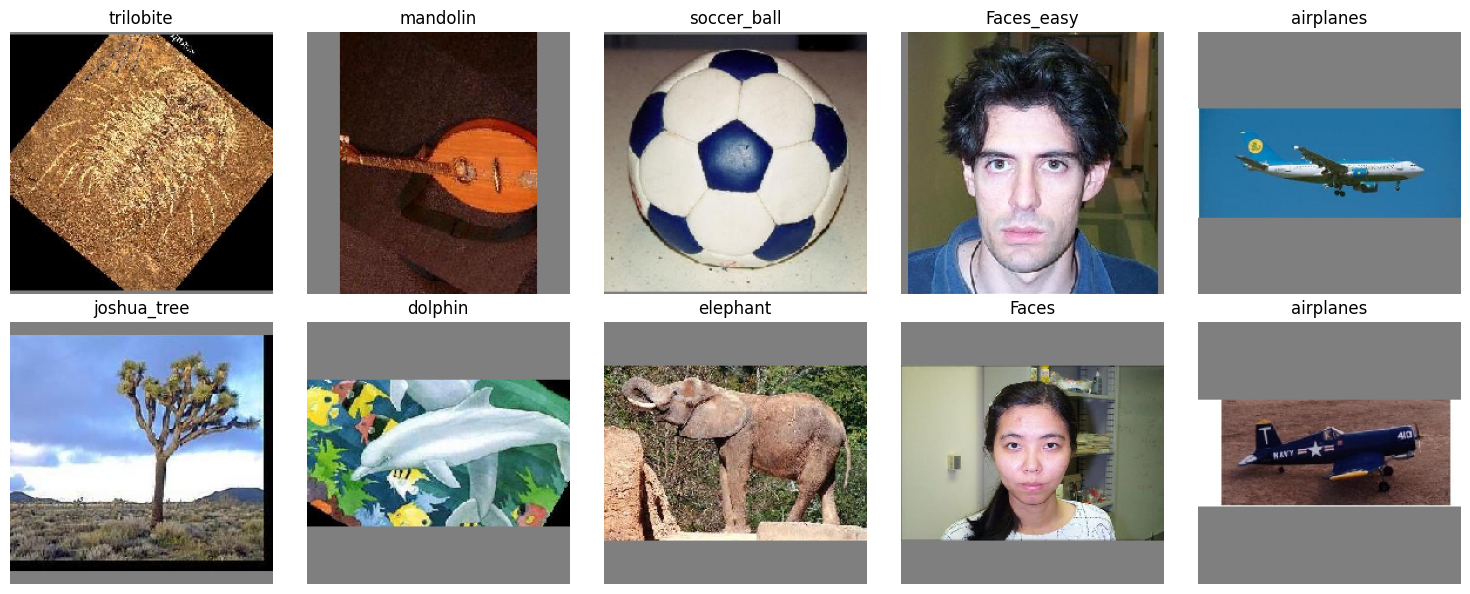

In [7]:
########################################################################################################################
# 6. UČITAVANJE PODATAKA
########################################################################################################################

image_size = 224
batch_size = 32

print("Učitavanje i pretprocesiranje slika...")
categories, train_images, test_images = load_data_def()
print("Broj trening slika:", len(train_images))
print("Broj test slika:", len(test_images))
print("Broj kategorija:", len(categories))

datagen_train = DataGenerator(batch_size=batch_size,
                              images=train_images,
                              image_size=image_size,
                              data_aug=True,
                              keep_aspect=True,
                              fill_value=(127,127,127))

datagen_test = DataGenerator(batch_size=batch_size,
                             images=test_images,
                             image_size=image_size,
                             data_aug=False,
                             keep_aspect=True,
                             fill_value=(127,127,127))

print("\nPrikaz prvih 10 slika iz test skupa...")
plt.figure(figsize=(15, 6))  # Širina i visina prozora za prikaz

batch_x, batch_y = datagen_test[0]
for i in range(10):
    plt.subplot(2, 5, i + 1)  # Kreiranje grida: 2 reda, 5 kolona, i-ta pozicija
    plt.imshow(np.clip(batch_x[i], 0, 255).astype(np.uint8))
    plt.title(categories[batch_y[i]])
    plt.axis('off')  # Isključivanje x i y osa radi preglednijeg prikaza slika

plt.tight_layout()  # Automatsko podešavanje razmaka između slika
plt.show()          # Prikaz grida u Colab ćeliji

In [8]:
########################################################################################################################
# 7. KREIRANJE MODELA
########################################################################################################################

model = create_model(image_size, classes=len(categories), trainable_encoder=False)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=tf.keras.losses.sparse_categorical_crossentropy,
              metrics=[tf.keras.metrics.sparse_categorical_accuracy])

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ keras_tensor_2CLONE │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ keras_tensor_2CL… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[1][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[1]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[1][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[1]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[1][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[1][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[1… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[1][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 171,397 (669.52 KB)

 Non-trainable params: 4,007,555 (15.29 MB)

Warmup training for 20 epochs...
Epoch 1/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 218s 703ms/step - loss: 2.6466 - sparse_categorical_accuracy: 0.4710 - val_loss: 0.9569 - val_sparse_categorical_accuracy: 0.8306
Epoch 2/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 96s 444ms/step - loss: 0.8616 - sparse_categorical_accuracy: 0.8064 - val_loss: 0.4078 - val_sparse_categorical_accuracy: 0.9107
Epoch 3/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 96s 442ms/step - loss: 0.4702 - sparse_categorical_accuracy: 0.8843 - val_loss: 0.2899 - val_sparse_categorical_accuracy: 0.9286
Epoch 4/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 96s 440ms/step - loss: 0.3557 - sparse_categorical_accuracy: 0.9061 - val_loss: 0.2497 - val_sparse_categorical_accuracy: 0.9378
Epoch 5/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 98s 450ms/step - loss: 0.2775 - sparse_categorical_accuracy: 0.9254 - val_loss: 0.2114 - val_sparse_categorical_accuracy: 0.9401
Epoch 6/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 98s 451ms/step - loss: 0.2307 - sparse_categorical_accuracy: 0.9365 - val_loss: 0

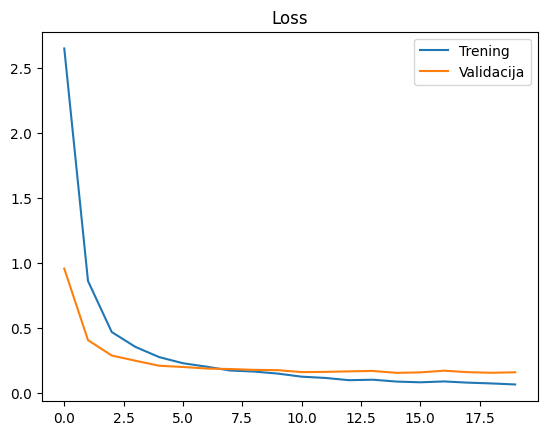

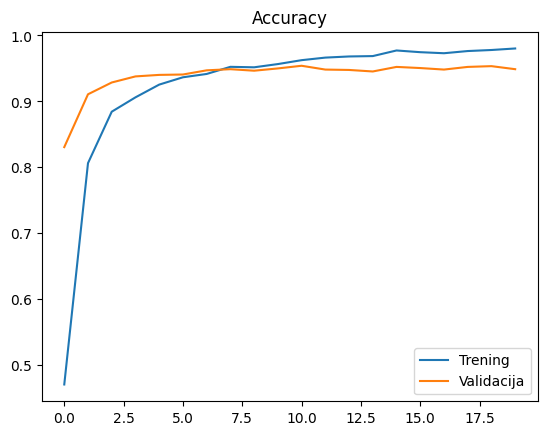

In [9]:
########################################################################################################################
# 8. INICIJALNO OBUČAVANJE MODELA (WARMUP TRAINING)
########################################################################################################################

# Logovanje CSV-a na Google Drive
csv_logger = tf.keras.callbacks.CSVLogger(os.path.join(drive_results_folder, 'warmup.csv'))

data_gen = get_data_generator()

print("Warmup training for 20 epochs...")
hist = model.fit(datagen_train,
                 epochs=20,
                 validation_data=datagen_test,
                 verbose=1,
                 callbacks=[csv_logger])

# Čuvanje modela na Google Drive
model_path = os.path.join(drive_results_folder, 'warmup_model.keras')
model.save(model_path, include_optimizer=False)
print(f"Model sačuvan na: {model_path}")

# Prikaz i čuvanje grafikona
plt.clf()
plt.plot(hist.history['loss'], label='Trening')
plt.plot(hist.history['val_loss'], label='Validacija')
plt.legend()
plt.title('Loss')
plt.savefig(os.path.join(drive_results_folder, 'warmup_loss.png'))
plt.show()

plt.clf()
plt.plot(hist.history['sparse_categorical_accuracy'], label='Trening')
plt.plot(hist.history['val_sparse_categorical_accuracy'], label='Validacija')
plt.legend()
plt.title('Accuracy')
plt.savefig(os.path.join(drive_results_folder, 'warmup_accuracy.png'))
plt.show()

Fine-tuning model...
Epoch 1/1000
217/217 ━━━━━━━━━━━━━━━━━━━━ 223s 692ms/step - loss: 0.0770 - sparse_categorical_accuracy: 0.9759 - val_loss: 0.1578 - val_sparse_categorical_accuracy: 0.9545 - learning_rate: 1.0000e-04
Epoch 2/1000
217/217 ━━━━━━━━━━━━━━━━━━━━ 98s 453ms/step - loss: 0.0702 - sparse_categorical_accuracy: 0.9782 - val_loss: 0.1555 - val_sparse_categorical_accuracy: 0.9533 - learning_rate: 1.0000e-04
Epoch 3/1000
217/217 ━━━━━━━━━━━━━━━━━━━━ 99s 454ms/step - loss: 0.0622 - sparse_categorical_accuracy: 0.9827 - val_loss: 0.1677 - val_sparse_categorical_accuracy: 0.9591 - learning_rate: 1.0000e-04
Epoch 4/1000
217/217 ━━━━━━━━━━━━━━━━━━━━ 96s 444ms/step - loss: 0.0482 - sparse_categorical_accuracy: 0.9853 - val_loss: 0.1623 - val_sparse_categorical_accuracy: 0.9522 - learning_rate: 1.0000e-04
Epoch 5/1000
217/217 ━━━━━━━━━━━━━━━━━━━━ 99s 456ms/step - loss: 0.0404 - sparse_categorical_accuracy: 0.9899 - val_loss: 0.1708 - val_sparse_categorical_accuracy: 0.9493 - learning_

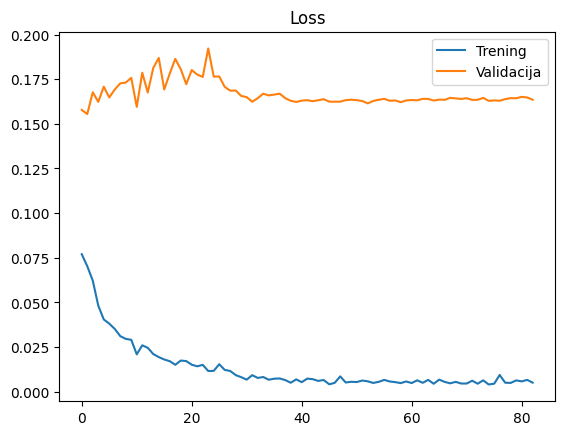

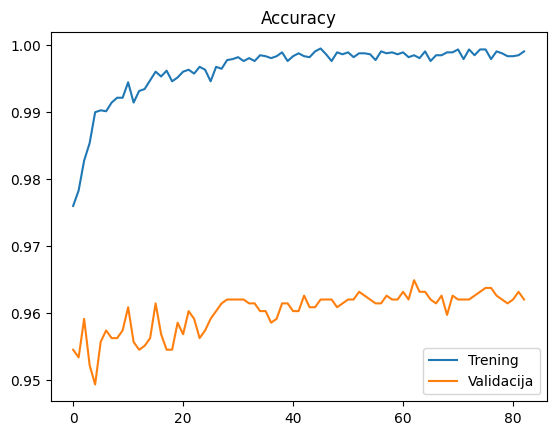

In [10]:
########################################################################################################################
# 9. FINO OBUČAVANJE MODELA (FINE-TUNING)
########################################################################################################################

# Otključavanje svih slojeva
for layer in model.layers:
    layer.trainable = True

# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_sparse_categorical_accuracy', mode='max',
                                                  patience=20, restore_best_weights=True, verbose=1)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_sparse_categorical_accuracy', mode='max',
                                                 factor=0.1, patience=10, verbose=1)

# Logovanje CSV-a na Google Drive
csv_logger = tf.keras.callbacks.CSVLogger(os.path.join(drive_results_folder, 'finetuning.csv'))

# Fine-tuning model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss=tf.keras.losses.sparse_categorical_crossentropy,
              metrics=[tf.keras.metrics.sparse_categorical_accuracy])

print("Fine-tuning model...")
hist = model.fit(datagen_train,
                 epochs=1000,
                 validation_data=datagen_test,
                 verbose=1,
                 callbacks=[early_stopping, reduce_lr, csv_logger])

# Čuvanje modela na Google Drive
model_path = os.path.join(drive_results_folder, 'finetuned_model.keras')
model.save(model_path, include_optimizer=False)
print(f"Model sačuvan na: {model_path}")

# Prikaz i čuvanje grafikona
plt.clf()
plt.plot(hist.history['loss'], label='Trening')
plt.plot(hist.history['val_loss'], label='Validacija')
plt.legend()
plt.title('Loss')
plt.savefig(os.path.join(drive_results_folder, 'finetuning_loss.png'))
plt.show()

plt.clf()
plt.plot(hist.history['sparse_categorical_accuracy'], label='Trening')
plt.plot(hist.history['val_sparse_categorical_accuracy'], label='Validacija')
plt.legend()
plt.title('Accuracy')
plt.savefig(os.path.join(drive_results_folder, 'finetuning_accuracy.png'))
plt.show()


Evaluacija modela...
Trening rezultati (Loss, Accuracy): [0.003524725092574954, 0.9987033605575562]
Test rezultati (Loss, Accuracy): [0.16397616267204285, 0.9648617506027222]
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 155ms/step

Pogrešne predikcije (61 komada) su sačuvane na Drive-u u folderu: /content/drive/MyDrive/Caltech101_v2_Results_Keras/misclassified

Prikaz prvih (do 25) loše klasifikovanih slika:


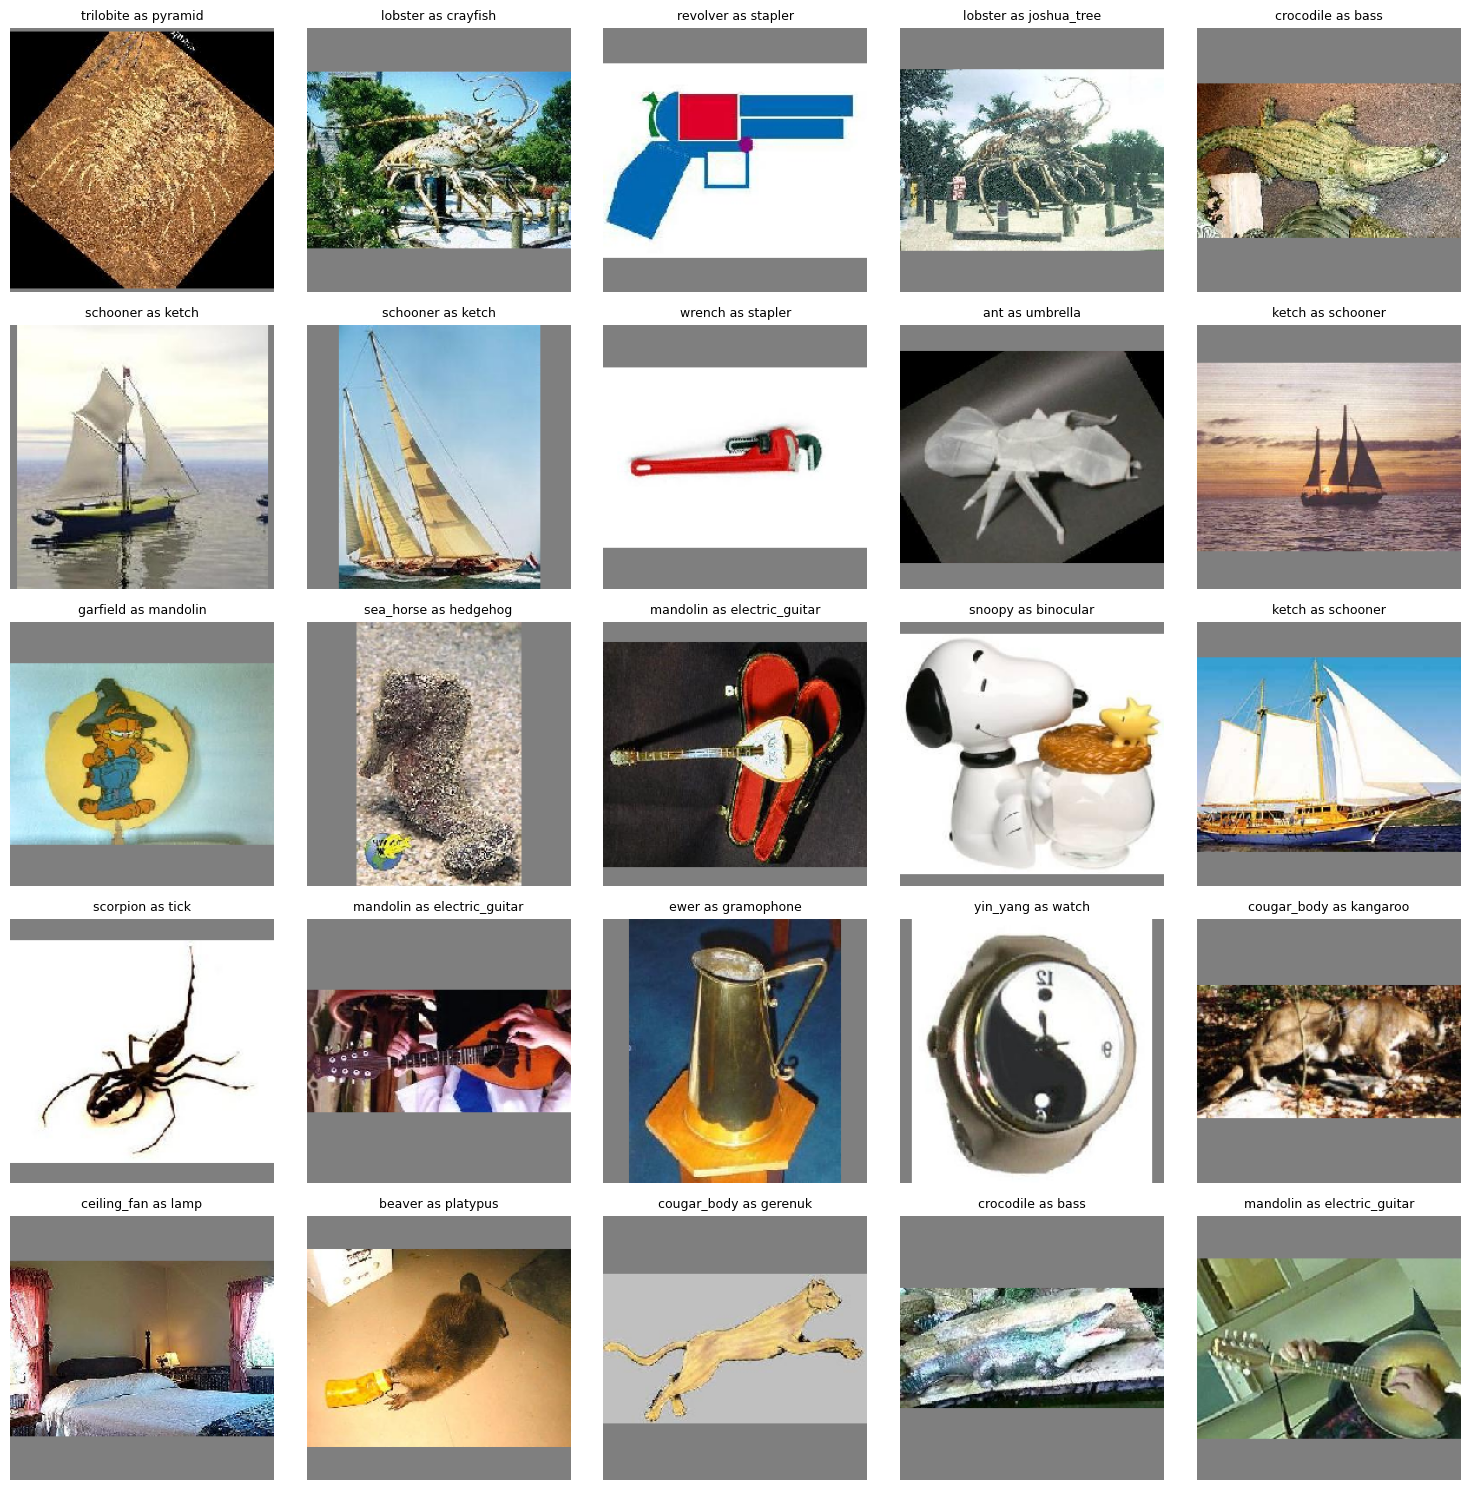

In [11]:
########################################################################################################################
# 10. EVALUACIJA MODELA
########################################################################################################################

print("\nEvaluacija modela...")
datagen_train_eval = DataGenerator(batch_size=batch_size,
                                   images=train_images,
                                   image_size=image_size,
                                   data_aug=False,
                                   keep_aspect=True)
res_train = model.evaluate(datagen_train_eval, batch_size=batch_size, verbose=0)
res_test = model.evaluate(datagen_test, batch_size=batch_size, verbose=0)
print(f"Trening rezultati (Loss, Accuracy): {res_train}")
print(f"Test rezultati (Loss, Accuracy): {res_test}")

# Izvlači sve labele za test podatke
test_labels = []
for i in range(len(datagen_test)):
    batch_x, batch_y = datagen_test[i]
    test_labels.extend(batch_y)
y_test = np.array(test_labels)

y_out = model.predict(datagen_test, batch_size=batch_size)
y_out = np.argmax(y_out, axis=1)

# Kreiranje podfoldera na Drive-u za pogrešne predikcije
misclassified_folder = os.path.join(drive_results_folder, 'misclassified')
if not os.path.exists(misclassified_folder):
    os.makedirs(misclassified_folder)

i = 0
misclassified_for_grid = [] # Lista u koju smeštamo prvih 25 grešaka za grid

# Iteriramo kroz ukupan broj test primera
for idx in range(len(y_test)):
    out = y_out[idx]
    exp = y_test[idx]

    if out != exp:
        i += 1
        title = '{} as {}'.format(categories[int(exp)], categories[int(out)])

        batch_idx = idx // batch_size   # računanje indeksa batch-a
        idx_in_batch = idx % batch_size # računanje indeksa slike u batch-u

        batch_x, _ = datagen_test[batch_idx]
        img = np.clip(batch_x[idx_in_batch], 0, 255).astype(np.uint8)

        # Čuvanje svake pogrešne slike na Drive
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(title)
        plt.savefig(os.path.join(misclassified_folder, '{} ({}).jpg'.format(i, title)))
        plt.close()

        # Zadržavanje prvih 25 slika za prikaz u Colab-u
        if len(misclassified_for_grid) < 25:
            misclassified_for_grid.append((img, title))

print(f"\nPogrešne predikcije ({i} komada) su sačuvane na Drive-u u folderu: {misclassified_folder}")

# Prikaz prvih 25 pogrešnih predikcija u gridu
if misclassified_for_grid:
    print("\nPrikaz prvih (do 25) loše klasifikovanih slika:")
    cols = 5
    # Računanje broja redova u slučaju da model ima manje od 25 grešaka ukupno
    rows = min(5, (len(misclassified_for_grid) + cols - 1) // cols)

    plt.figure(figsize=(15, 3 * rows))
    for idx, (img, title) in enumerate(misclassified_for_grid):
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img)
        plt.title(title, fontsize=9) # Nešto manji font da bi stao u grid
        plt.axis('off')

    plt.tight_layout()
    plt.show()